In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
import pandas as pd

df = pd.read_excel("../data/Mall_Customers.xlsx")
df.head()


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [9]:
df.to_csv("../data/Mall_Customers.csv", index=False)


In [10]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [12]:
import pandas as pd

df = pd.read_csv("../data/Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [13]:
df.shape


(200, 7)

In [14]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status',
       'Annual Income (k$)', 'Spending Score (1-100)'],
      dtype='str')

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Education               200 non-null    str  
 4   Marital Status          200 non-null    str  
 5   Annual Income (k$)      200 non-null    int64
 6   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(3)
memory usage: 11.1 KB


In [16]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [17]:
df.shape
df.columns
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Education               200 non-null    str  
 4   Marital Status          200 non-null    str  
 5   Annual Income (k$)      200 non-null    int64
 6   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(3)
memory usage: 11.1 KB


CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


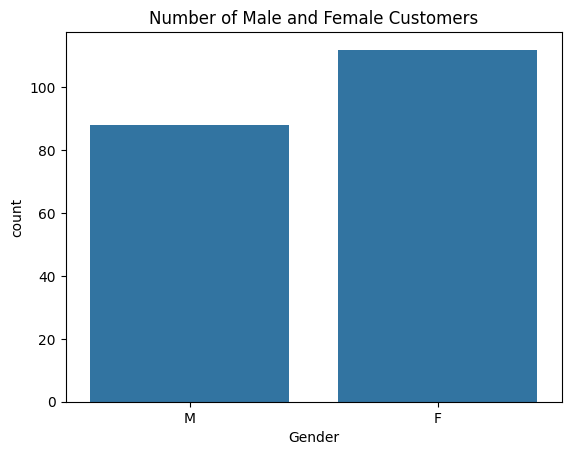

In [19]:
sns.countplot(x='Gender', data=df)
plt.title("Number of Male and Female Customers")
plt.show()


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


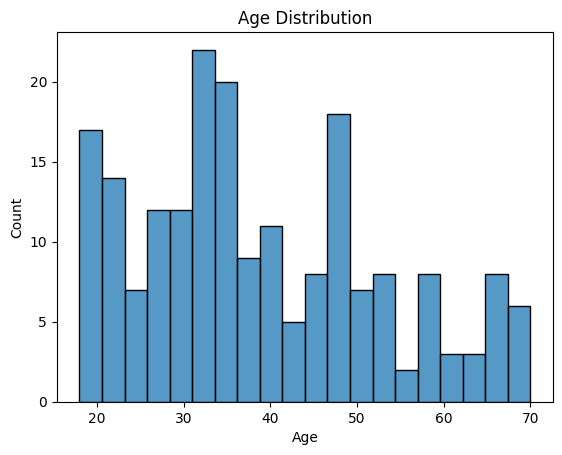

In [6]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

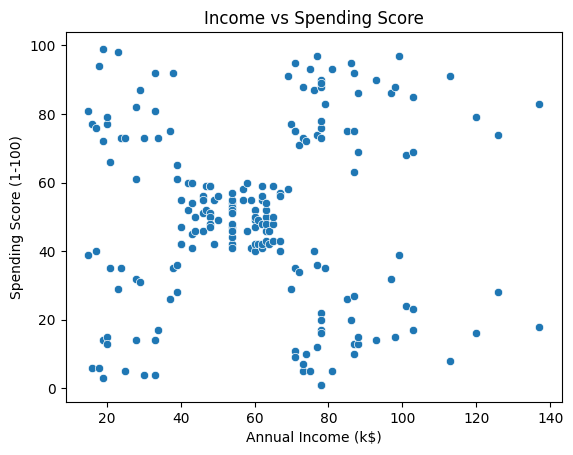

In [7]:
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

In [8]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
from sklearn.cluster import KMeans

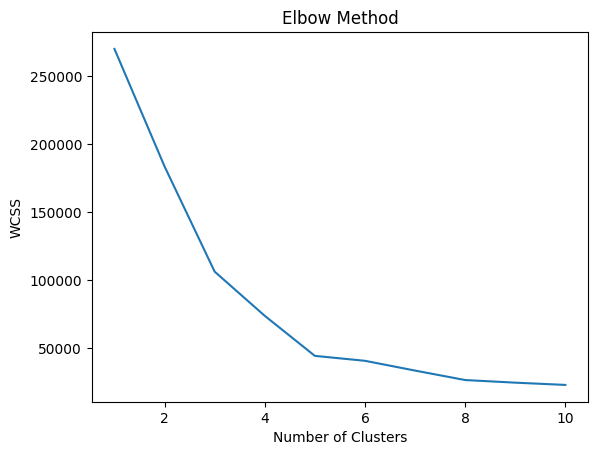

In [10]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,M,19,High School,Married,15,39,4
1,2,M,21,Graduate,Single,15,81,2
2,3,F,20,Graduate,Married,16,6,4
3,4,F,23,High School,Unknown,16,77,2
4,5,F,31,Uneducated,Married,17,40,4


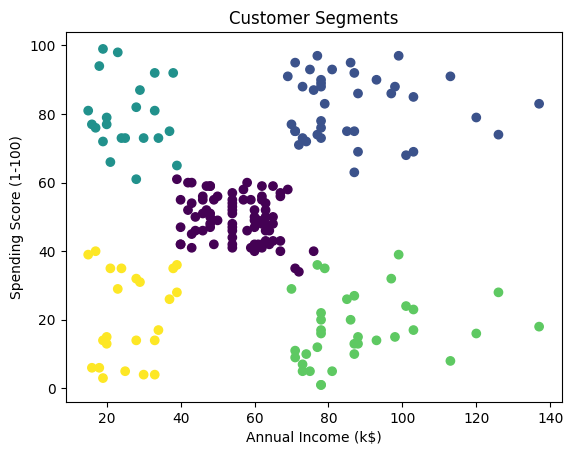

In [12]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()

In [14]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [16]:
df.groupby('Cluster')['Spending Score (1-100)'].mean()

Cluster
0    49.518519
1    82.128205
2    79.363636
3    17.114286
4    20.913043
Name: Spending Score (1-100), dtype: float64

In [15]:
df.groupby('Cluster')['Annual Income (k$)'].mean()

Cluster
0    55.296296
1    86.538462
2    25.727273
3    88.200000
4    26.304348
Name: Annual Income (k$), dtype: float64

In [17]:
df['Cluster'].value_counts()


Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [18]:
df.to_csv("../output/Customer_Segmentation_Result.csv", index=False)